In [1]:
# Data and analysis libraries
import polars as pl                         # Fast dataframes for financial data
import numpy as np                          # Numerical computing library
from datetime import datetime, timedelta    # Date and time operations
import random


# Machine learning libraries  
import torch                                # PyTorch framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms
import research                             # Model building and training utilities


# Visualization and 
import altair as alt                        # Interactive visualization library

# data sources
import binance                              # Binance market data utilities

# Load Model

In [2]:
import models

model = models.LinearModel(3)
model.load_state_dict(torch.load('model_weights.pth', weights_only=True))
model.eval()

LinearModel(
  (linear): Linear(in_features=3, out_features=1, bias=True)
)

### Model Parameters

In [3]:
research.print_model_params(model)

linear.weight:
[[-0.05877389 -0.01687386 -0.02073925]]
linear.bias:
[0.00028092]


### Mean Reversion

In [4]:
series = [-0.014000, 0.011399, -0.012212, 0.01997, -0.01442, 0.01227]
mu = np.mean(series)
mean_reversion_df = pl.DataFrame({'log_return': series, 'mean': mu})
mean_reversion_df

log_return,mean
f64,f64
-0.014,0.000501
0.011399,0.000501
-0.012212,0.000501
0.01997,0.000501
-0.01442,0.000501
0.01227,0.000501


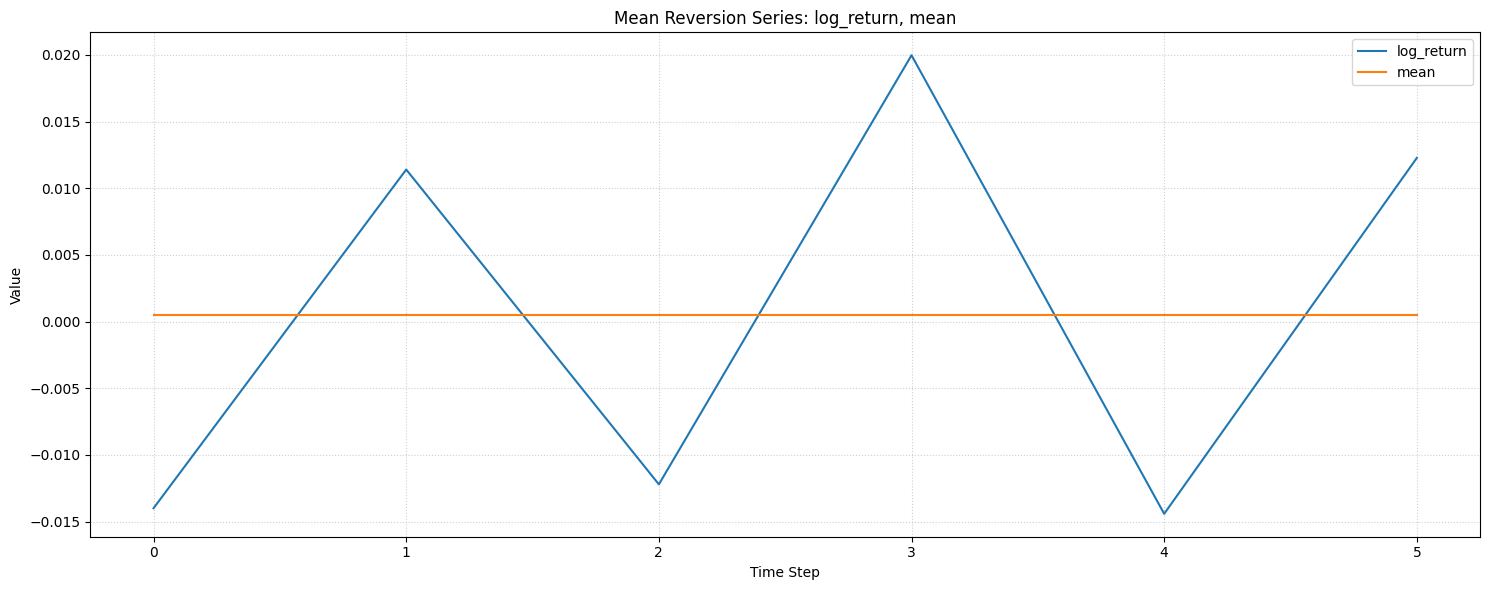

In [5]:
research.plot_multiple_lines(mean_reversion_df, ['log_return','mean'], 'Mean Reversion')

### Interpretability - Linear Model

In [6]:
def linear_model(x):
    w, b = -0.09911217, 0.00059838
    return w * x + b

linear_model(-0.015)

0.00208506255

In [7]:
linear_model(0.02)

-0.0013838634

### Interpretability - Non Linear Model

In [8]:
def nn_model(x):
    x = torch.tensor([x])
    W = torch.tensor([0.08035, -0.01478, -0.03523,  0.06777,  0.03789,  0.0013991, -0.13303,  0.8045])
    b = torch.tensor([0.16421])
    return torch.tanh(torch.sum(x * W) + b)

nn_model(-0.015)

tensor([0.1509])

In [9]:
# no interability
nn_model(0.02)

tensor([0.1785])

## Strategy Development

### Load Time Series

In [10]:
sym = 'BTCUSDT'
time_interval = '12h'

ts = pl.read_csv(f'{sym}_{time_interval}_ohlc.csv', try_parse_dates=True).sort('datetime')
ts

datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71440.1
2024-10-29 12:00:00,71440.0,73660.0,70900.0,72739.5
2024-10-30 00:00:00,72739.5,72797.4,71931.1,71995.0
2024-10-30 12:00:00,71994.9,72984.9,71444.2,72349.0
2024-10-31 00:00:00,72349.0,72720.3,72030.5,72213.3
…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5


### Add Target and Features

In [11]:
forecast_horizon = 1
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=3)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71440.1,null,null,null,null
2024-10-29 12:00:00,71440.0,73660.0,70900.0,72739.5,0.018025,null,null,null
2024-10-30 00:00:00,72739.5,72797.4,71931.1,71995.0,-0.010288,0.018025,null,null
2024-10-30 12:00:00,71994.9,72984.9,71444.2,72349.0,0.004905,-0.010288,0.018025,null
2024-10-31 00:00:00,72349.0,72720.3,72030.5,72213.3,-0.001877,0.004905,-0.010288,0.018025
…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858


In [12]:
test_size = 0.25
_, trades = research.timeseries_split(ts, test_size)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597
…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858


# Strategy
### 1. Entry / Exit Signal

### Add Model Predictation

In [13]:
target = 'close_log_return'
features = [f'{target}_lag_{i}' for i in range(1, 4)]
trades = research.add_model_predictions(trades, model, features)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259,0.001435
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.000637
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,0.000159
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,0.000106
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.000435
…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933,0.000204
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757,0.001723
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858,0.000006


### Add Directional Signal

In [14]:
trades = trades.with_columns(pl.col('y_hat').sign().alias('dir_signal'))
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259,0.001435,1.0
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.000637,1.0
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,0.000159,1.0
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,0.000106,1.0
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.000435,1.0
…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933,0.000204,1.0
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757,0.001723,1.0
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858,0.000006,1.0


### Calculate Trade Log Return

In [15]:
trades = trades.with_columns(
    (pl.col('close_log_return') * pl.col('dir_signal')).alias('trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259,0.001435,1.0,0.005349
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.000637,1.0,0.008597
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,0.000159,1.0,-0.001385
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,0.000106,1.0,-0.005257
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.000435,1.0,0.010185
…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933,0.000204,1.0,-0.025324
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757,0.001723,1.0,0.012611
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858,0.000006,1.0,0.003347


### Calculate Cumulative Trade Log Return

In [16]:
trades = trades.with_columns(
    (pl.col('trade_log_return').cum_sum()).alias('cum_trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259,0.001435,1.0,0.005349,0.005349
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.000637,1.0,0.008597,0.013946
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,0.000159,1.0,-0.001385,0.012561
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,0.000106,1.0,-0.005257,0.007304
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.000435,1.0,0.010185,0.017489
…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933,0.000204,1.0,-0.025324,-0.073517
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757,0.001723,1.0,0.012611,-0.060906
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858,0.000006,1.0,0.003347,-0.057559


### Display Equity Curve (Log Space)

In [17]:
research.plot_column(trades, 'cum_trade_log_return')

alt.Chart(...)

### 2. Trade size

In [18]:
capital = 100
ratio = 1.0
trade_value = capital * ratio

trades = trades.with_columns(
    pl.lit(trade_value).alias('entry_trade_value'),
    (trade_value * pl.col('trade_log_return').exp()).alias('exit_trade_value'),
    (trade_value / pl.col('open')).alias('trade_qty')
).with_columns(
    (pl.col('trade_qty') * pl.col('dir_signal')).alias('signed_trade_qty')
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty
datetime[μs],f64,f64,f64,f32,f64,f64,f64
2025-07-15 12:00:00,117110.4,117738.5,0.005349,0.001435,100.0,100.536332,0.000854
2025-07-16 00:00:00,117738.6,118755.1,0.008597,0.000637,100.0,100.863439,0.000849
2025-07-16 12:00:00,118755.1,118590.7,-0.001385,0.000159,100.0,99.861564,0.000842
2025-07-17 00:00:00,118590.7,117968.9,-0.005257,0.000106,100.0,99.475676,0.000843
2025-07-17 12:00:00,117968.8,119176.6,0.010185,0.000435,100.0,101.023744,0.000848
…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,121286.5,-0.025324,0.000204,100.0,97.499381,0.000804
2025-10-08 00:00:00,121286.6,122825.7,0.012611,0.001723,100.0,101.269061,0.000824
2025-10-08 12:00:00,122825.8,123237.5,0.003347,0.000006,100.0,100.335272,0.000814


### Add Trade Gross PnL

In [19]:
trades = trades.with_columns(
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl')
)
trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,117738.5,0.005349,0.001435,100.0,100.536332,0.000854,0.536332
2025-07-16 00:00:00,117738.6,118755.1,0.008597,0.000637,100.0,100.863439,0.000849,0.863439
2025-07-16 12:00:00,118755.1,118590.7,-0.001385,0.000159,100.0,99.861564,0.000842,-0.138436
2025-07-17 00:00:00,118590.7,117968.9,-0.005257,0.000106,100.0,99.475676,0.000843,-0.524324
2025-07-17 12:00:00,117968.8,119176.6,0.010185,0.000435,100.0,101.023744,0.000848,1.023744
…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,121286.5,-0.025324,0.000204,100.0,97.499381,0.000804,-2.500619
2025-10-08 00:00:00,121286.6,122825.7,0.012611,0.001723,100.0,101.269061,0.000824,1.269061
2025-10-08 12:00:00,122825.8,123237.5,0.003347,0.000006,100.0,100.335272,0.000814,0.335272


### Add Transaction Fee

In [20]:
taker_fee = binance.TAKER_FEE
maker_fee = binance.MAKER_FEE

trades = trades.with_columns(
    ((pl.col('entry_trade_value') + pl.col('exit_trade_value')) * taker_fee).alias('taker_fee'),
    ((pl.col('entry_trade_value') + pl.col('exit_trade_value')) * maker_fee).alias('maker_fee'),
).with_columns(
    (pl.col('taker_fee') + pl.col('maker_fee')).alias('total_fee')
)
trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl', 'taker_fee', 'maker_fee', 'total_fee')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,total_fee
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,117738.5,0.005349,0.001435,100.0,100.536332,0.000854,0.536332,0.090241,0.090241,0.180483
2025-07-16 00:00:00,117738.6,118755.1,0.008597,0.000637,100.0,100.863439,0.000849,0.863439,0.090389,0.090389,0.180777
2025-07-16 12:00:00,118755.1,118590.7,-0.001385,0.000159,100.0,99.861564,0.000842,-0.138436,0.089938,0.089938,0.179875
2025-07-17 00:00:00,118590.7,117968.9,-0.005257,0.000106,100.0,99.475676,0.000843,-0.524324,0.089764,0.089764,0.179528
2025-07-17 12:00:00,117968.8,119176.6,0.010185,0.000435,100.0,101.023744,0.000848,1.023744,0.090461,0.090461,0.180921
…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,121286.5,-0.025324,0.000204,100.0,97.499381,0.000804,-2.500619,0.088875,0.088875,0.177749
2025-10-08 00:00:00,121286.6,122825.7,0.012611,0.001723,100.0,101.269061,0.000824,1.269061,0.090571,0.090571,0.181142
2025-10-08 12:00:00,122825.8,123237.5,0.003347,0.000006,100.0,100.335272,0.000814,0.335272,0.090151,0.090151,0.180302


### Calculat Trade Net PnL

In [21]:
trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('total_fee')).alias('trade_net_pnl')
)
trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl', 'total_fee', 'trade_net_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,total_fee,trade_net_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,117738.5,0.005349,0.001435,100.0,100.536332,0.000854,0.536332,0.180483,0.355849
2025-07-16 00:00:00,117738.6,118755.1,0.008597,0.000637,100.0,100.863439,0.000849,0.863439,0.180777,0.682662
2025-07-16 12:00:00,118755.1,118590.7,-0.001385,0.000159,100.0,99.861564,0.000842,-0.138436,0.179875,-0.318312
2025-07-17 00:00:00,118590.7,117968.9,-0.005257,0.000106,100.0,99.475676,0.000843,-0.524324,0.179528,-0.703853
2025-07-17 12:00:00,117968.8,119176.6,0.010185,0.000435,100.0,101.023744,0.000848,1.023744,0.180921,0.842823
…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,121286.5,-0.025324,0.000204,100.0,97.499381,0.000804,-2.500619,0.177749,-2.678368
2025-10-08 00:00:00,121286.6,122825.7,0.012611,0.001723,100.0,101.269061,0.000824,1.269061,0.181142,1.087919
2025-10-08 12:00:00,122825.8,123237.5,0.003347,0.000006,100.0,100.335272,0.000814,0.335272,0.180302,0.15497


### Display Equity Curve for Constant Sizing

In [22]:
def equity_curve(capital, col_name, suffix):
    return (capital + pl.col(col_name).cum_sum()).alias(f'equity_curve_{suffix}')

trades = trades.with_columns(
    equity_curve(capital, 'trade_gross_pnl', 'gross'),
    equity_curve(capital, 'trade_net_pnl', 'net')
)
trades.select('datetime', 'equity_curve_gross', 'equity_curve_net')

datetime,equity_curve_gross,equity_curve_net
datetime[μs],f64,f64
2025-07-15 12:00:00,100.536332,100.355849
2025-07-16 00:00:00,101.39977,101.038511
2025-07-16 12:00:00,101.261334,100.720199
2025-07-17 00:00:00,100.73701,100.016347
2025-07-17 12:00:00,101.760754,100.85917
…,…,…
2025-10-07 12:00:00,93.524335,63.110163
2025-10-08 00:00:00,94.793396,64.198082
2025-10-08 12:00:00,95.128668,64.353052


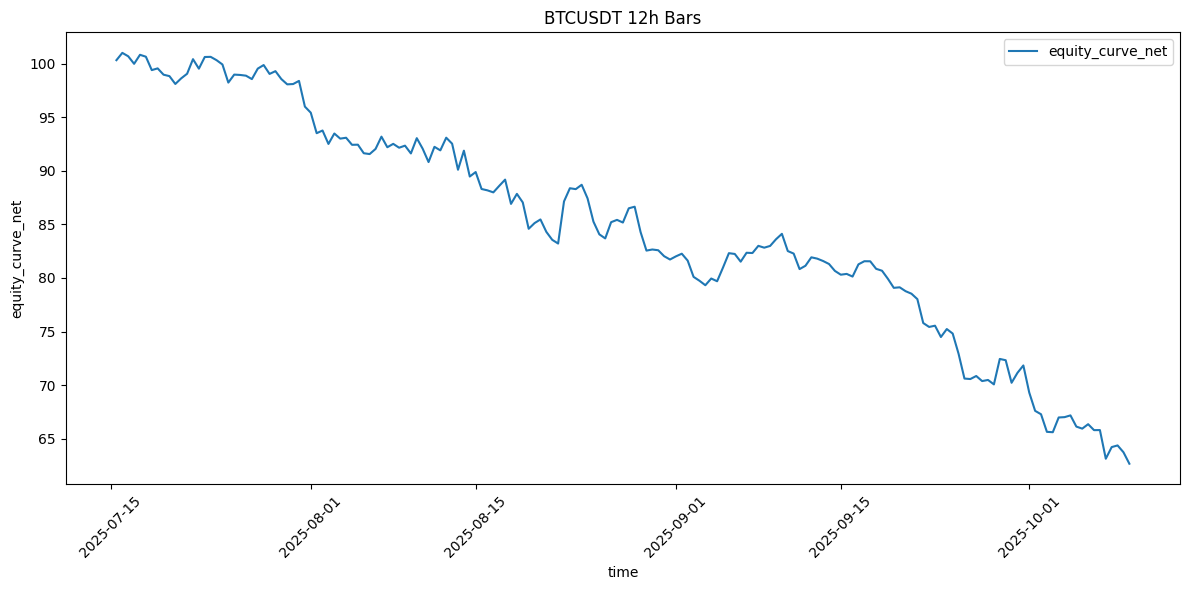

In [23]:
research.plot_static_timeseries(trades, sym, 'equity_curve_net', time_interval)

### Calculate Total Net Return using Constant Sizing

In [24]:
constant_sizing_net_return = trades['equity_curve_net'][-1] / capital - 1
constant_sizing_net_return

-0.3735534955999029

### Compounding Trade Sizing

In [25]:
trades = trades.with_columns(
    ((pl.col('cum_trade_log_return').exp() * capital)).shift().fill_null(capital).alias('entry_trade_value'),
    ((pl.col('cum_trade_log_return').exp() * capital)).alias('exit_trade_value')
).with_columns(
    (pl.col('entry_trade_value') / pl.col('open') * pl.col('dir_signal')).alias('signed_trade_qty'),
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl')
)
trades.select('datetime', 'open', 'close', 'trade_log_return', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

datetime,open,close,trade_log_return,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,117738.5,0.005349,100.0,100.536332,0.000854,0.536332
2025-07-16 00:00:00,117738.6,118755.1,0.008597,100.536332,101.404401,0.000854,0.86807
2025-07-16 12:00:00,118755.1,118590.7,-0.001385,101.404401,101.264021,0.000854,-0.14038
2025-07-17 00:00:00,118590.7,117968.9,-0.005257,101.264021,100.733069,0.000854,-0.530952
2025-07-17 12:00:00,117968.8,119176.6,0.010185,100.733069,101.764318,0.000854,1.031249
…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,121286.5,-0.025324,95.295025,92.91206,0.000766,-2.382965
2025-10-08 00:00:00,121286.6,122825.7,0.012611,92.91206,94.091171,0.000766,1.179111
2025-10-08 12:00:00,122825.8,123237.5,0.003347,94.091171,94.406632,0.000766,0.315461


In [26]:
trades = research.add_tx_fees(trades, binance.MAKER_FEE, binance.TAKER_FEE)
trades.select('datetime', 'entry_trade_value', 'exit_trade_value', 'tx_fee_maker', 'tx_fee_taker')

datetime,entry_trade_value,exit_trade_value,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64
2025-07-15 12:00:00,100.0,100.536332,0.090241,0.090241
2025-07-16 00:00:00,100.536332,101.404401,0.090873,0.090873
2025-07-16 12:00:00,101.404401,101.264021,0.091201,0.091201
2025-07-17 00:00:00,101.264021,100.733069,0.090899,0.090899
2025-07-17 12:00:00,100.733069,101.764318,0.091124,0.091124
…,…,…,…,…
2025-10-07 12:00:00,95.295025,92.91206,0.084693,0.084693
2025-10-08 00:00:00,92.91206,94.091171,0.084151,0.084151
2025-10-08 12:00:00,94.091171,94.406632,0.084824,0.084824


### Add Trade Net PnL

In [27]:
trades = trades.with_columns(
    (pl.col('tx_fee_maker') + pl.col('tx_fee_taker')).alias('total_fee')
).with_columns(
    (pl.col('trade_gross_pnl') - pl.col('total_fee')).alias('trade_net_pnl')
)
trades.select('datetime', 'entry_trade_value', 'exit_trade_value', 'trade_gross_pnl', 'total_fee', 'trade_net_pnl')

datetime,entry_trade_value,exit_trade_value,trade_gross_pnl,total_fee,trade_net_pnl
datetime[μs],f64,f64,f64,f64,f64
2025-07-15 12:00:00,100.0,100.536332,0.536332,0.180483,0.355849
2025-07-16 00:00:00,100.536332,101.404401,0.86807,0.181747,0.686323
2025-07-16 12:00:00,101.404401,101.264021,-0.14038,0.182402,-0.322782
2025-07-17 00:00:00,101.264021,100.733069,-0.530952,0.181797,-0.712749
2025-07-17 12:00:00,100.733069,101.764318,1.031249,0.182248,0.849001
…,…,…,…,…,…
2025-10-07 12:00:00,95.295025,92.91206,-2.382965,0.169386,-2.552352
2025-10-08 00:00:00,92.91206,94.091171,1.179111,0.168303,1.010808
2025-10-08 12:00:00,94.091171,94.406632,0.315461,0.169648,0.145813


### Display Equity Curve (Compounding)

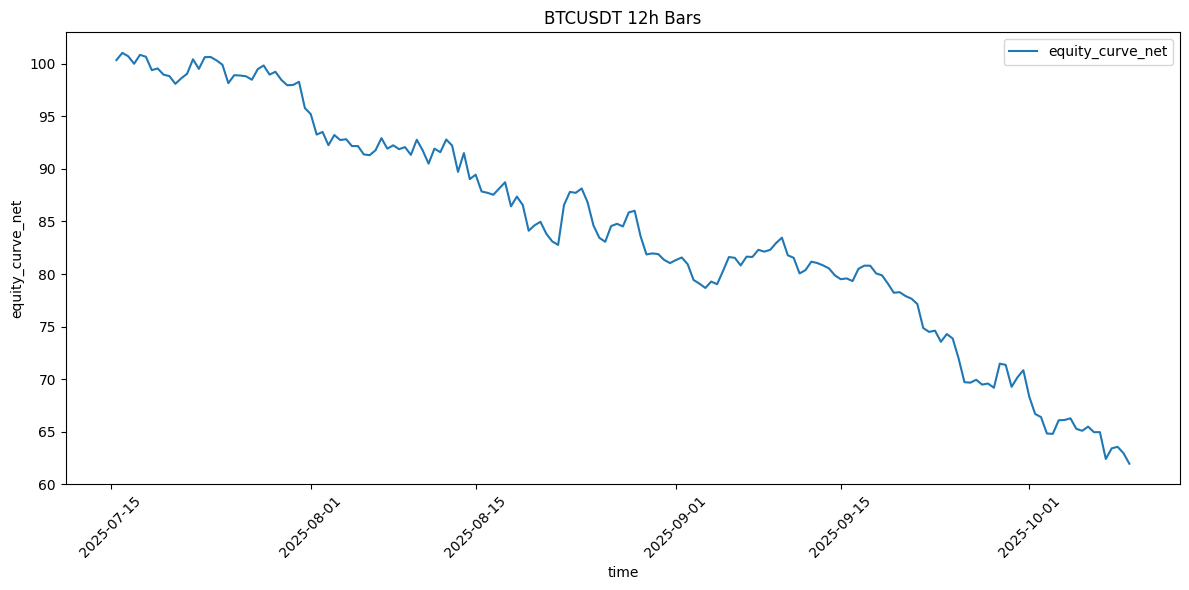

In [28]:
trades = research.add_equity_curve(trades, capital, 'trade_net_pnl', 'net')
research.plot_static_timeseries(trades, sym, 'equity_curve_net', time_interval)

### Calculate Total Net Return for Compounding Trade Sizing

In [29]:
compound_total_net_return = trades['equity_curve_net'][-1] / capital - 1
compound_total_net_return

-0.3805109353162738

In [30]:
constant_sizing_net_return

-0.3735534955999029

In [31]:
np.round(compound_total_net_return - constant_sizing_net_return, 2)

np.float64(-0.01)

### 3. Leverage

In [32]:
leverage = 2

In [33]:
trades = research.add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,total_fee,trade_net_pnl,equity_curve_gross,equity_curve_net,tx_fee_maker,tx_fee_taker,trade_net_taker_pnl,trade_net_maker_pnl,equity_curve_taker,equity_curve_maker
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259,0.001435,1.0,0.005349,0.005349,200.0,201.072663,0.000854,0.001708,1.072663,0.090241,0.090241,0.180483,0.355849,101.072663,100.355849,0.180483,0.180483,0.89218,0.89218,100.89218,100.89218
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.000637,1.0,0.008597,0.013946,201.072663,202.808803,0.000849,0.001708,1.73614,0.090389,0.090389,0.181747,0.686323,102.808803,101.042172,0.181747,0.181747,1.554393,1.554393,102.446573,102.446573
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,0.000159,1.0,-0.001385,0.012561,202.808803,202.528042,0.000842,0.001708,-0.280761,0.089938,0.089938,0.182402,-0.322782,102.528042,100.71939,0.182402,0.182402,-0.463162,-0.463162,101.983411,101.983411
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,0.000106,1.0,-0.005257,0.007304,202.528042,201.466138,0.000843,0.001708,-1.061904,0.089764,0.089764,0.181797,-0.712749,101.466138,100.006641,0.181797,0.181797,-1.243701,-1.243701,100.73971,100.73971
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.000435,1.0,0.010185,0.017489,201.466138,203.528636,0.000848,0.001708,2.062498,0.090461,0.090461,0.182248,0.849001,103.528636,100.855642,0.182248,0.182248,1.880251,1.880251,102.61996,102.61996
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933,0.000204,1.0,-0.025324,-0.073517,190.59005,185.82412,0.000804,0.001532,-4.765931,0.088875,0.088875,0.169386,-2.552352,85.82412,62.400499,0.169386,0.169386,-4.935317,-4.935317,55.312559,55.312559
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757,0.001723,1.0,0.012611,-0.060906,185.82412,188.182341,0.000824,0.001532,2.358222,0.090571,0.090571,0.168303,1.010808,88.182341,63.411307,0.168303,0.168303,2.189919,2.189919,57.502478,57.502478
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858,0.000006,1.0,0.003347,-0.057559,188.182341,188.813264,0.000814,0.001532,0.630922,0.090151,0.090151,0.169648,0.145813,88.813264,63.55712,0.169648,0.169648,0.461274,0.461274,57.963752,57.963752


### Calculate Total Net Return

In [34]:
trades['equity_curve_net'][-1] / capital - 1

-0.3805109353162738

### Factor Liquidation

In [39]:
maintenance_margin = 0.005

def long_liquidation_price(position, leverage, maintenance_margin):
    return (position * leverage) / (leverage + 1 - maintenance_margin * leverage)

def short_liquidation_price(position, leverage, maintenance_margin):
    return (position * leverage) / (leverage - 1 + maintenance_margin * leverage)

In [40]:
long_liquidation_price(200, leverage, maintenance_margin)

133.7792642140468

In [41]:
short_liquidation_price(200, leverage, maintenance_margin)

396.03960396039605

### Add liquidation price

In [42]:
trades = trades.with_columns(
    pl.when(
        pl.col('dir_signal') == 1
    ).then(
        (pl.col('open') * leverage / (leverage + 1 - maintenance_margin * leverage))
    ).when(
        pl.col('dir_signal') == -1
    ).then(
        (pl.col('open') * leverage / (leverage - 1 + maintenance_margin * leverage))
    ).otherwise(None).alias('liquidation_price')
)

trades.select('datetime', 'open', 'high', 'low', 'close', 'liquidation_price', 'dir_signal')

datetime,open,high,low,close,liquidation_price,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f32
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,78334.715719,1.0
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,78754.916388,1.0
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,79434.849498,1.0
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,79324.882943,1.0
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,78908.896321,1.0
…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,83208.762542,1.0
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,81128.160535,1.0
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,82157.725753,1.0


### Add Liquidation Flag

In [44]:
trades = trades.with_columns([
    # Worst price based on direction
    pl.when(
        pl.col('dir_signal') == 1
    ).then(
        pl.col('low')
    ).otherwise(
        pl.col('high')
    ).alias('worst_price'),

    # Liquidation flag
    pl.when(
        (pl.col('dir_signal') == 1) & (pl.col('low') <= pl.col('liquidation_price'))
    ).then(True)
    .when(
        (pl.col('dir_signal') == -1) & (pl.col('high') >= pl.col('liquidation_price'))
    ).then(True)
    .otherwise(False)
    .alias('liquidated')
])

trades.select('datetime', 'open', 'high', 'low', 'close', 'dir_signal', 'worst_price' ,'liquidation_price', 'liquidated')

datetime,open,high,low,close,dir_signal,worst_price,liquidation_price,liquidated
datetime[μs],f64,f64,f64,f64,f32,f64,f64,bool
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,1.0,115678.1,78334.715719,false
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,1.0,117017.1,78754.916388,false
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,1.0,118156.0,79434.849498,false
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,1.0,117663.6,79324.882943,false
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,1.0,117412.8,78908.896321,false
…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,1.0,120516.0,83208.762542,false
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,1.0,121005.3,81128.160535,false
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,1.0,121607.8,82157.725753,false


### Find Liquidated Trade

In [45]:
trades.filter(pl.col('liquidated') == True)

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,total_fee,trade_net_pnl,equity_curve_gross,equity_curve_net,tx_fee_maker,tx_fee_taker,trade_net_taker_pnl,trade_net_maker_pnl,equity_curve_taker,equity_curve_maker,liquidation_price,worst_price,liquidated
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
